In [1]:
%cd ../..

f:\nn


# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms

from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utils.training import train_model, evaluate_model
from utils.visualization import plot_training_curves, plot_confusion_matrix
from utils.dataset import CrackDataset
from utils.config import RNN_CONFIG, RNN_SEARCH_SPACE
from utils.hparam_search import run_search, plot_search_results

f:\nn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Importing our dataset

,class,resized_path
0,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
1,Non Cracked,data\augmented_images\7050-6_resized_aug2.jpeg
2,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
3,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
4,Non Cracked,data\augmented_images\7119-100_resized_aug2.jpeg
5,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
6,Non Cracked,data\augmented_images\14397_resized_aug0.jpeg
7,Non Cracked,data\augmented_images\16418_resized_aug0.jpeg
8,Non Cracked,data\augmented_images\047-50_resized_aug1.jpeg
9,Non Cracked,data\augmented_images\7103-214_resized_aug1.jpeg


Class distribution:


<Axes: xlabel='class'>

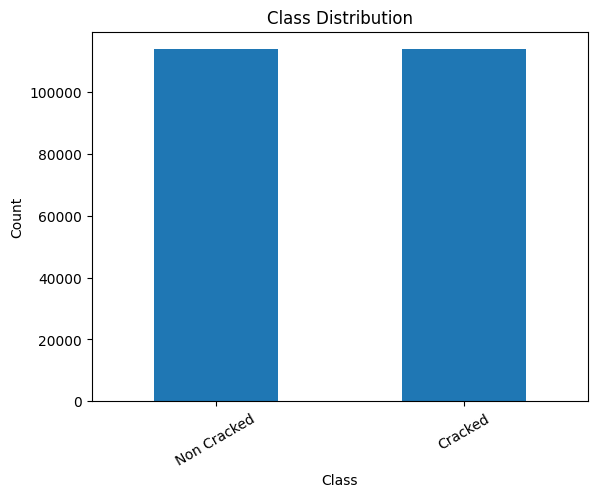

In [3]:
df = pd.read_csv('data/trainable_df.csv')
display(df.head(10))
print("="*80)
print("Class distribution:")
display(df['class'].value_counts().plot(kind='bar'))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# Preparing our data

## Image resize

> For the RNN we resize images to 64×64 rather than 128×128 or 227x227. The LSTM processes the image as a sequence of rows — each row of 64 pixel values is fed in as one timestep, giving 64 timesteps in total. Using 128×128 produced 128 timesteps, which caused vanishing gradients: by the time the LSTM reached the last row, gradients flowing back to the early rows had shrunk to near zero, causing the hidden state to collapse to the same vector regardless of input. Reducing to 64×64 halves the sequence length, giving the LSTM a better chance of retaining useful information across the full image while still preserving enough spatial detail to detect crack patterns.


In [4]:
transformations = transforms.Compose([
    transforms.Resize((RNN_CONFIG['image_size'], RNN_CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.Lambda(lambda x: x.squeeze(0)),  # (1, H, W) → (H, W) for LSTM
])

classes = sorted(df['class'].unique())
dataset = CrackDataset(df, transform=transformations, classes=classes)

n = len(dataset)
train_dataset = int(n * 0.8)
val_dataset   = int(n * 0.1)
test_dataset  = n - train_dataset - val_dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_dataset, val_dataset, test_dataset],
    generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}")
print(f"Classes: {classes}")
print(f"Class→idx: {dataset.class_to_idx}")

Train: 182,297  |  Val: 22,787  |  Test: 22,788
Classes: ['Cracked', 'Non Cracked']
Class→idx: {'Cracked': 0, 'Non Cracked': 1}


# Initializing the DataLoader

The `DataLoader` wraps each split in a batched iterator. `shuffle=True` on the training set prevents the model from memorising sample order. Validation and test loaders use `shuffle=False` so metrics are fully reproducible.

In [5]:
train_loader = DataLoader(train_dataset, batch_size=RNN_CONFIG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=RNN_CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=RNN_CONFIG['batch_size'], shuffle=False, num_workers=0)

In [6]:
class RNN(nn.Module):
    """
    An LSTM-based RNN for binary crack classification.

    The image is treated as a sequence of rows — each row of pixels is one
    timestep. The LSTM processes all rows sequentially, building up a hidden
    state that summarises everything seen so far. The final hidden state
    (after the last row) is passed through a fully-connected classifier.

    Input shape:  (batch, 64, 64) — grayscale image with channel dim removed.
    Output shape: (batch, num_classes)
    """

    def __init__(self, input_size: int, hidden_size: int, num_layers: int,
                 num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)
        
        for p in self.parameters():
            p.register_hook(lambda grad: torch.clamp(grad, -1.0, 1.0))

    def forward(self, x):
        out, _ = self.lstm(x)        # out: (batch, seq_len, hidden_size)
        return self.classifier(out[:, -1, :])  # last timestep → (batch, num_classes)


model = RNN(
    input_size=RNN_CONFIG['image_size'],
    hidden_size=RNN_CONFIG['hidden_size'],
    num_layers=RNN_CONFIG['num_layers'],
    num_classes=len(classes),
    dropout=RNN_CONFIG['dropout'],
)

# Optimizer and loss function

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=RNN_CONFIG['lr'],
    weight_decay=RNN_CONFIG['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training our data

## Training using our GPU

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def build_rnn(params, num_classes):
    model     = RNN(
        input_size=RNN_CONFIG['image_size'],
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        num_classes=num_classes,
        dropout=params['dropout']
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()
    return model, optimizer, scheduler, criterion

In [ ]:
best_params, trial_histories = run_search(
    build_rnn,
    train_loader, val_loader,
    RNN_SEARCH_SPACE, 
    classes,
    results_path='Models/RNN/best_hparams.json',
)

Pre-loading 54,689 samples into RAM...
Done.
Pre-loading 22,787 samples into RAM...
Done.

Trial 1/30 — lr=1.25e-03, weight_decay=3.41e-04, dropout=4.95e-01, batch_size=64, hidden_size=256, num_layers=3


Epoch 1/50 [val]: 100%|██████████| 357/357 [00:02<00:00, 162.13it/s]

Epoch 1/50 | Train Loss: 0.6921 | Train Acc: 0.5186 | Val Loss: 0.6909 | Val Acc: 0.5244 | LR: 1.25e-03



Epoch 2/50 [val]: 100%|██████████| 357/357 [00:02<00:00, 159.62it/s]

Epoch 2/50 | Train Loss: 0.6914 | Train Acc: 0.5250 | Val Loss: 0.6903 | Val Acc: 0.5276 | LR: 1.25e-03


...

Epoch 38/50 | Train Loss: 0.5402 | Train Acc: 0.7067 | Val Loss: 0.5419 | Val Acc: 0.7091 | LR: 1.67e-04



Epoch 39/50 [val]: 100%|██████████| 713/713 [00:01<00:00, 623.05it/s]

Epoch 39/50 | Train Loss: 0.5402 | Train Acc: 0.7065 | Val Loss: 0.5416 | Val Acc: 0.7103 | LR: 8.36e-05



Epoch 40/50 [val]: 100%|██████████| 713/713 [00:01<00:00, 614.59it/s]

Epoch 40/50 | Train Loss: 0.5389 | Train Acc: 0.7070 | Val Loss: 0.5417 | Val Acc: 0.7087 | LR: 8.36e-05
Early stopping at epoch 40 (no improvement for 5 epochs)
  -> best val_loss=0.5415 over 40 epochs

Best trial #14  val_loss=0.5035
Params: {'lr': 0.000372619541375375, 'weight_decay': 6.766893267235256e-06, 'dropout': 0.3251721106544003, 'batch_size': 32, 'hidden_size': 256, 'num_layers': 2}
Saved to Models\RNN\best_hparams.json


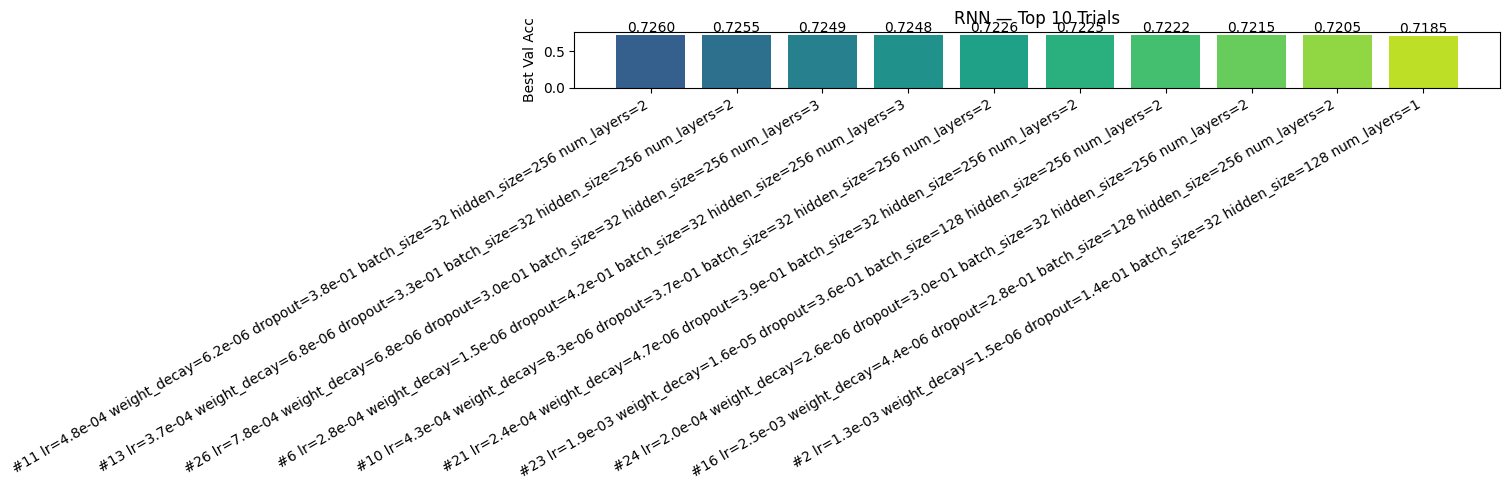

In [11]:
plot_search_results(trial_histories, metric='val_acc', title='RNN — Top 10 Trials', top_n=10)

# Plotting our training, validation losses

In [12]:
RNN_CONFIG.update(best_params)
model     = RNN(
    input_size=RNN_CONFIG['image_size'],
    hidden_size=RNN_CONFIG['hidden_size'],
    num_layers=RNN_CONFIG['num_layers'],
    num_classes=len(classes),
    dropout=RNN_CONFIG['dropout']
)
optimizer = torch.optim.Adam(model.parameters(),
                              lr=RNN_CONFIG['lr'],
                              weight_decay=RNN_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [ ]:
history = train_model(build_rnn, train_loader, val_loader,
                      params=best_params, num_classes=len(classes),
                      epochs=RNN_CONFIG['epochs'], device=device,
                      patience=RNN_CONFIG['patience'],
                      save_path='Models/saved_models/rnn_best.pth')

Epoch 1/150 [val]: 100%|██████████| 357/357 [00:01<00:00, 228.90it/s]

Epoch 1/150 | Train Loss: 0.6492 | Train Acc: 0.5924 | Val Loss: 0.5718 | Val Acc: 0.6896 | LR: 3.73e-04


  -> Saved best model (val_loss=0.5718)


Epoch 2/150 [val]: 100%|██████████| 357/357 [00:01<00:00, 239.90it/s]

Epoch 2/150 | Train Loss: 0.5614 | Train Acc: 0.6929 | Val Loss: 0.5602 | Val Acc: 0.6927 | LR: 3.73e-04


...

Epoch 24/150 | Train Loss: 0.4354 | Train Acc: 0.7560 | Val Loss: 0.4950 | Val Acc: 0.7356 | LR: 9.32e-05



Epoch 25/150 [val]: 100%|██████████| 357/357 [00:01<00:00, 243.20it/s]

Epoch 25/150 | Train Loss: 0.4256 | Train Acc: 0.7608 | Val Loss: 0.5065 | Val Acc: 0.7358 | LR: 9.32e-05



Epoch 26/150 [val]: 100%|██████████| 357/357 [00:01<00:00, 222.34it/s]

Epoch 26/150 | Train Loss: 0.4217 | Train Acc: 0.7625 | Val Loss: 0.5089 | Val Acc: 0.7351 | LR: 9.32e-05
Early stopping at epoch 26 (no improvement for 10 epochs)


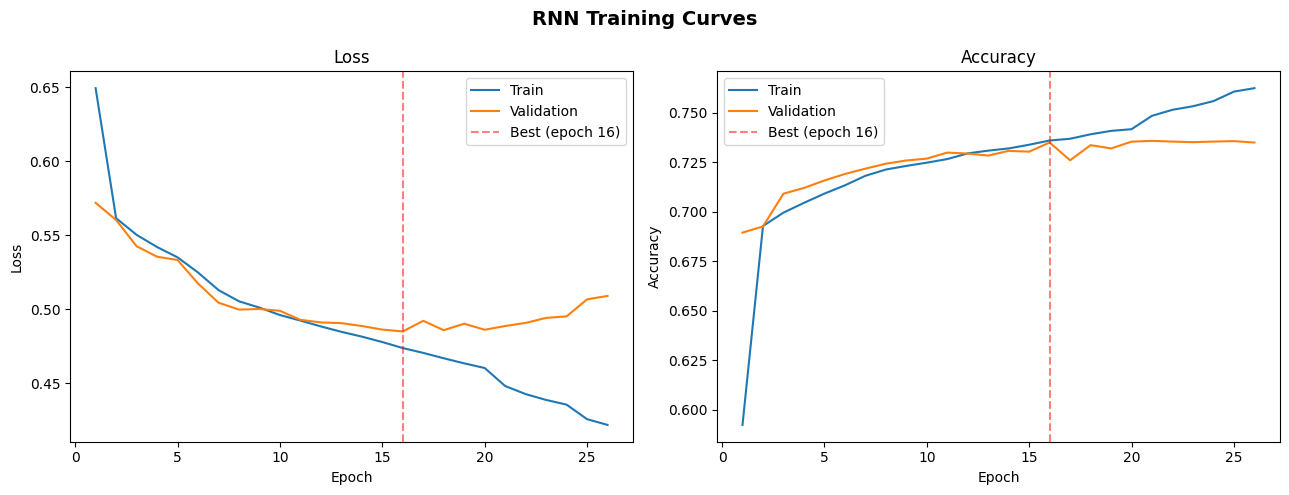

In [14]:
plot_training_curves(history, title="RNN Training Curves")

# Evaluation

We reload the best checkpoint before running inference — `train_model` saves it during training but the `model` variable in memory holds the last epoch, not the best one.

In [16]:
model = RNN(input_size=RNN_CONFIG['image_size'], hidden_size=RNN_CONFIG['hidden_size'], num_layers=RNN_CONFIG['num_layers'], num_classes=len(classes), dropout=RNN_CONFIG['dropout'])
checkpoint = torch.load('Models/saved_models/rnn_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"| val_loss={checkpoint['val_loss']:.4f} | val_acc={checkpoint['val_acc']:.4f}")
model.to(device)

Loaded best model from epoch 16 | val_loss=0.4849 | val_acc=0.7351


RNN(
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)

Classification Report:
              precision    recall  f1-score   support

     Cracked       0.89      0.53      0.67     11341
 Non Cracked       0.67      0.93      0.78     11447

    accuracy                           0.73     22788
   macro avg       0.78      0.73      0.72     22788
weighted avg       0.78      0.73      0.72     22788



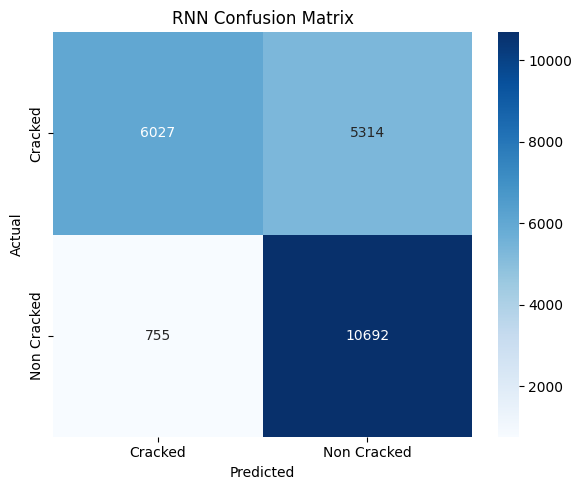

In [17]:
all_preds, all_labels = evaluate_model(model, test_loader, device=device)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))
plot_confusion_matrix(all_labels, all_preds, class_names=classes, title='RNN Confusion Matrix')